Mounted at /content/drive
Found existing installation: lightgbm 4.6.0
Uninstalling lightgbm-4.6.0:
  Successfully uninstalled lightgbm-4.6.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 88.4 MB/s eta 0:00:00

All imports successful. LightGBM version: 4.6.0

Starting LightGBM GPU training process...
LightGBM GPU Training for PlantVillage
Data loaded successfully:
- Training samples: 43444
- Test samples: 10861
- Features: 1280
- Classes: 38

Training LightGBM model on GPU...
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warni

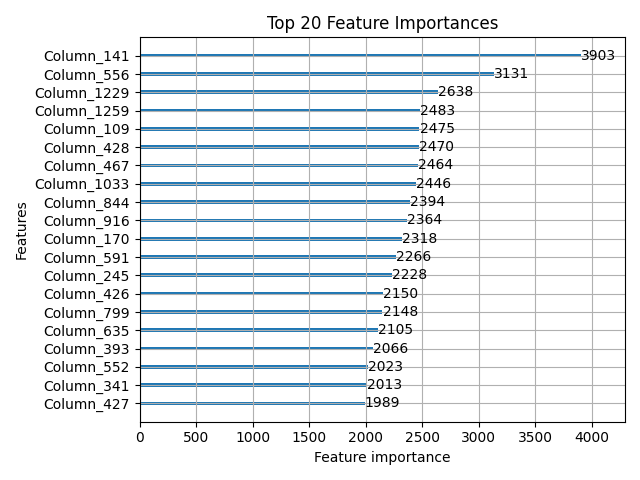


CONFUSION MATRIX:


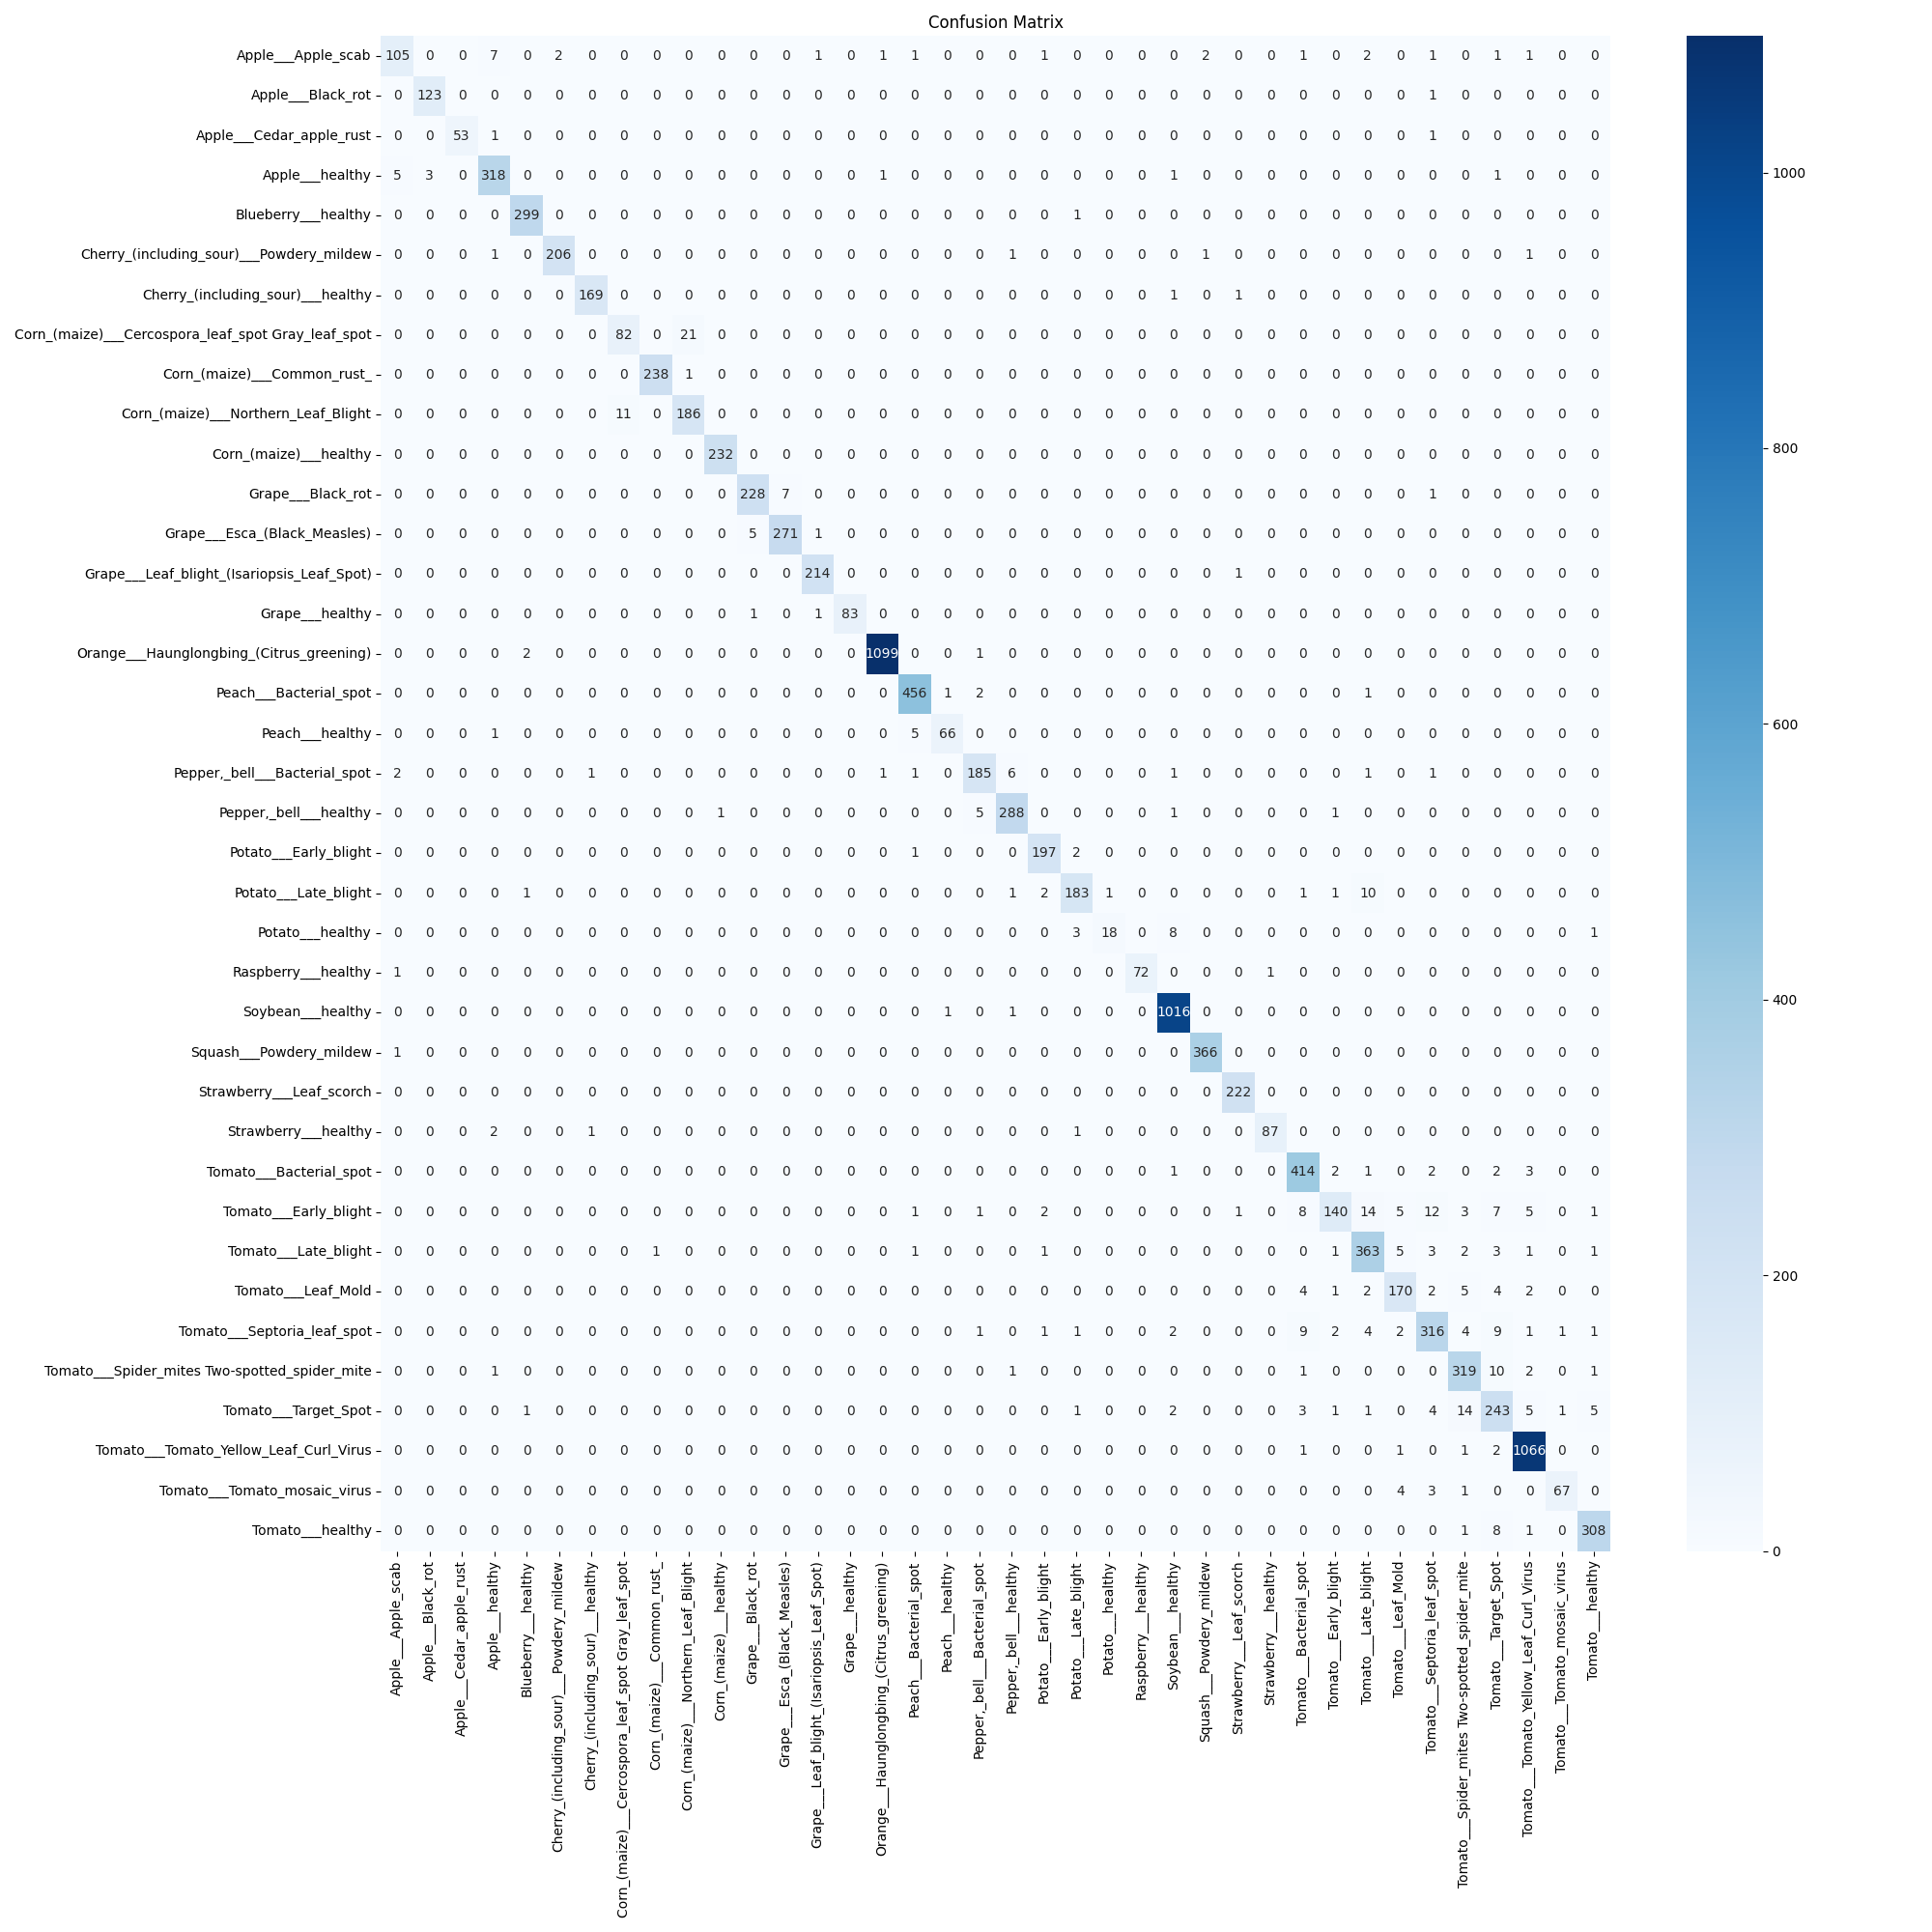


Workflow complete! Check your Google Drive for the GPU-trained model.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 1. Install GPU-enabled LightGBM
!pip uninstall lightgbm -y
!pip install lightgbm --config-settings=cmake.args="-DUSE_GPU=1"

# 2. Modern Imports
import os
import sys
import lightgbm as lgb
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import Image, display

print(f"\nAll imports successful. LightGBM version: {lgb.__version__}")

# 3. Setup Paths & Directories
sys.path.append('/content/drive/MyDrive/PlantVillage_Project/code/scripts')
os.makedirs('/content/drive/MyDrive/PlantVillage_Project/models/lightgbm', exist_ok=True)
os.makedirs('/content/drive/MyDrive/PlantVillage_Project/evaluation/lightgbm', exist_ok=True)

# 4. Run Training
print("\nStarting LightGBM GPU training process...")
!python "/content/drive/MyDrive/PlantVillage_Project/code/scripts/light_gbm.py"

# 5. Display Results from Drive
print("\n" + "="*30)
print("LightGBM GPU Results Analysis")
print("="*30)

eval_path = '/content/drive/MyDrive/PlantVillage_Project/evaluation/lightgbm/'
report_file = os.path.join(eval_path, 'classification_report.txt')
feat_img = os.path.join(eval_path, 'feature_importance.png')
cm_img = os.path.join(eval_path, 'confusion_matrix.png')

if os.path.exists(report_file):
    with open(report_file, 'r') as f:
        print("\nCLASSIFICATION REPORT:")
        print(f.read())

if os.path.exists(feat_img):
    print("\nFEATURE IMPORTANCE:")
    display(Image(filename=feat_img))

if os.path.exists(cm_img):
    print("\nCONFUSION MATRIX:")
    display(Image(filename=cm_img))

print("\nWorkflow complete! Check your Google Drive for the GPU-trained model.")